<a href="https://colab.research.google.com/github/BinRaditz/2026-AI-Engineer-SS6-Hackathon/blob/main/601710_Bin_Hackathon1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hackathon DATA


Author: Mr.BIN RAHCHAHUN

Number: 601710

# 📦IMPORT LIBRARIES & SETUP

In [ ]:
# ── Standard library ─────────────────────────────────────────────────────────
import warnings
import textwrap
import urllib.request

# ── Data & numerics ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Statistics & signal processing ───────────────────────────────────────────
from scipy import stats
from scipy.signal import savgol_filter

# ── Global settings ───────────────────────────────────────────────────────────
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":        130,
})

# ── Colour palette (shared across all charts) ─────────────────────────────────
PALETTE = {
    "primary":    "#1B4F72",
    "secondary":  "#2E86C1",
    "accent":     "#E74C3C",
    "highlight":  "#F39C12",
    "green":      "#27AE60",
    "light_blue": "#AED6F1",
    "bg":         "#F7F9FC",
    "grid":       "#E5E8EC",
}

DISTRICT_COLORS = sns.color_palette("tab20", 18)

# ── Lookup tables ─────────────────────────────────────────────────────────────

# Thai month abbreviation → English 3-letter
THAI_MONTH_MAP = {
    "ม.ค.":  "Jan", "ก.พ.":  "Feb", "มี.ค.": "Mar",
    "เม.ย.": "Apr", "พ.ค.":  "May", "มิ.ย.": "Jun",
    "ก.ค.":  "Jul", "ส.ค.":  "Aug", "ก.ย.":  "Sep",
    "ต.ค.":  "Oct", "พ.ย.":  "Nov", "ธ.ค.":  "Dec",
}

MONTH_ORDER = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Buddhist Era → Common Era offset
BE_TO_CE = 543

# Thai district name → English transliteration
DISTRICT_MAP = {
    "บางพลี":      "Bang Phli",
    "วัดเลียบ":    "Wat Liap",
    "สามเสน":      "Sam Sen",
    "บางบัวทอง":   "Bang Bua Thong",
    "นนทบุรี":     "Nonthaburi",
    "นวลจันทร์":   "Nuan Chan",
    "บางใหญ่":     "Bang Yai",
    "ลาดกระบัง":   "Lat Krabang",
    "บางกะปิ":     "Bang Kapi",
    "มีนบุรี":     "Min Buri",
    "บางเขน":      "Bang Khen",
    "ราษฎร์บูรณะ": "Rat Burana",
    "สมุทรปราการ": "Samut Prakan",
    "คลองเตย":     "Khlong Toei",
    "ธนบุรี":      "Thon Buri",
    "บางขุนเทียน": "Bang Khun Thian",
    "ยานนาวา":     "Yan Nawa",
    "บางนา":       "Bang Na",
}

# Known real-world events for anomaly annotation
KNOWN_EVENTS = {
    (2020, "Mar"): "COVID-19\nLockdown",
    (2020, "Apr"): "COVID-19\nLockdown",
    (2021, "Jan"): "2nd Wave\nCOVID",
    (2023, "Apr"): "Heat Wave\n2023",
    (2023, "May"): "Heat Wave\n2023",
    (2024, "Apr"): "Heat Wave\n2024",
    (2024, "May"): "Heat Wave\n2024",
}

print("✅  Cell 1 complete — libraries imported, constants defined.")

✅  Cell 1 complete — libraries imported, constants defined.


# 📥LOAD DATA FROM GITHUB

In [ ]:
# ── GitHub raw URL ────────────────────────────────────────────────────────────
GITHUB_URL = (
    "https://raw.githubusercontent.com/BinRaditz/2026-AI-Engineer-SS6-Hackathon"
    "/5a1d880460fcc3b69db2535ae58331c76b1110e6"
    "/Hackathon1%20Hacathon1%20Data%20Cleansing%20Challenge/E68.csv"
)
LOCAL_PATH = "E68.csv"

# ── Download ──────────────────────────────────────────────────────────────────
print("⬇  Downloading E68.csv from GitHub …")
urllib.request.urlretrieve(GITHUB_URL, LOCAL_PATH)
print(f"✅  Saved locally → {LOCAL_PATH}")

# ── Quick raw preview ─────────────────────────────────────────────────────────
raw_preview = pd.read_csv(LOCAL_PATH, header=0, dtype=str,
                          encoding="utf-8-sig", nrows=5)
print(f"\n📄 Raw shape preview — first 5 rows × {raw_preview.shape[1]} cols:")
print(raw_preview.to_string())

print("\n✅  Cell 2 complete — data downloaded.")

⬇  Downloading E68.csv from GitHub …
✅  Saved locally → E68.csv

📄 Raw shape preview — first 5 rows × 21 cols:
     ปี    เดือน  วัดเลียบ   คลองเตย   ยานนาวา   บางกะปิ   มีนบุรี   สมุทรปราการ   บางพลี   สามเสน   นนทบุรี   บางใหญ่   ธนบุรี   ราษฎร์บูรณะ   บางขุนเทียน   บางเขน   บางนา   บางบัวทอง   ลาดกระบัง   นวลจันทร์  (หักไฟทำการ)
0  2562    ม.ค.       93.96    375.86    154.62    243.49     156.7        400.83   409.56   291.46    274.67     134.9   152.69        321.13        199.88   239.95  220.28       146.7      152.37      150.26     4,119.31
1   NaN    ก.พ.       94.88    373.54    156.55     248.9    161.21        396.36   408.68   298.58    287.13    142.73   158.55        314.98        202.95   254.82  222.29      152.47      155.39      158.49     4,188.50
2   NaN   มี.ค.      103.27    412.09    170.67    272.89    180.84        445.57   458.59   328.44    323.46    159.21   174.84        361.92        225.96   281.99   246.6       172.7       167.9         174     4,660.

#🔍EDA, Filter & Clean

## CLEANING FUNCTION

วิธีการทำความสะอาดข้อมูล (Data Cleaning) ในขั้นตอนนี้เริ่มจากการปรับรูปแบบชื่อคอลัมน์ให้เป็นมาตรฐาน โดยลบเครื่องหมาย BOM และช่องว่างที่ไม่จำเป็นออกจากชื่อคอลัมน์ทั้งหมด จากนั้นเปลี่ยนชื่อคอลัมน์ภาษาไทยให้เป็นชื่อที่ใช้ในการประมวลผล เช่น year_be และ month_th ต่อมาจะเติมค่าปีในแถวที่ว่างด้วยวิธี forward-fill เพื่อให้แถวข้อมูลย่อยยังคงใช้ปีเดียวกัน จากนั้นทำความสะอาดคอลัมน์เดือนโดยลบช่องว่างและแปลงตัวย่อเดือนภาษาไทยให้เป็นภาษาอังกฤษ และลบแถวที่ไม่สามารถแปลงเดือนได้ออกไป หลังจากนั้นจะแปลงปีพุทธศักราช (BE) ให้เป็นคริสต์ศักราช (CE) โดยลบค่า 543 แล้วสร้างคอลัมน์วันที่ (datetime) จากปีคริสต์ศักราชและเดือนภาษาอังกฤษ ต่อไปจะลบเครื่องหมายคอมมาในตัวเลขของทุกคอลัมน์ข้อมูลและแปลงชนิดข้อมูลเป็นตัวเลขแบบ float รวมถึงเปลี่ยนชื่อคอลัมน์ผลรวม (หักไฟทำการ) เป็น total_gwh จากนั้นทำความสะอาดและแปลงชื่อคอลัมน์ของทั้ง 18 เขตให้เป็นภาษาอังกฤษ สุดท้ายเรียงข้อมูลตามวันที่ รีเซ็ตดัชนีของตาราง และตรวจสอบคุณภาพข้อมูลโดยนับค่าที่หายไปและตรวจสอบวันที่ที่ซ้ำกัน เพื่อให้มั่นใจว่าข้อมูลพร้อมสำหรับการวิเคราะห์ต่อไป

In [ ]:
def load_and_clean(filepath: str) -> tuple[pd.DataFrame, list[str]]:

    log: list[str] = []

    # ── Step 1–2: Read CSV, clean headers ─────────────────────────────────────
    raw = pd.read_csv(filepath, header=0, dtype=str, encoding="utf-8-sig")
    raw.columns = [c.strip() for c in raw.columns]
    raw.rename(columns={"ปี": "year_be", "เดือน": "month_th"}, inplace=True)
    log.append(f"[LOAD]   Raw shape : {raw.shape[0]} rows × {raw.shape[1]} cols")
    log.append("[CLEAN]  Stripped whitespace from all column headers.")

    # ── Step 3: Forward-fill year ─────────────────────────────────────────────
    n_ffill = raw["year_be"].isna().sum()
    raw["year_be"] = raw["year_be"].ffill()
    log.append(f"[CLEAN]  Forward-filled {n_ffill} blank year cells.")

    # ── Step 4–5: Map Thai month → English; drop unmapped rows ────────────────
    raw["month_th"] = raw["month_th"].str.strip()
    raw["month_en"] = raw["month_th"].map(THAI_MONTH_MAP)
    unmapped = raw["month_en"].isna().sum()
    raw.dropna(subset=["month_en"], inplace=True)
    log.append(f"[CLEAN]  Thai months mapped → English. "
               f"Dropped {unmapped} unmappable rows.")

    # ── Step 6–7: BE → CE; build datetime ─────────────────────────────────────
    raw["year_ce"] = raw["year_be"].astype(int) - BE_TO_CE
    raw["date"] = pd.to_datetime(
        raw["year_ce"].astype(str) + "-" + raw["month_en"], format="%Y-%b"
    )
    log.append(f"[CLEAN]  Buddhist Era → CE (−{BE_TO_CE}). "
               f"Year range : {raw['year_ce'].min()}–{raw['year_ce'].max()}")
    log.append("[CLEAN]  Created 'date' column (datetime, YYYY-Mon).")

    # ── Step 8: Remove commas; cast all value columns → float ─────────────────
    skip = {"year_be", "month_th", "month_en", "year_ce", "date"}
    numeric_cols = [c for c in raw.columns if c not in skip]

    def to_float(s: pd.Series) -> pd.Series:
        return s.str.replace(",", "", regex=False).astype(float)

    for col in numeric_cols:
        raw[col] = to_float(raw[col])
    log.append(f"[CLEAN]  Removed thousands commas; "
               f"cast {len(numeric_cols)} columns → float.")

    # ── Step 9: Rename total column ───────────────────────────────────────────
    raw.rename(columns={"(หักไฟทำการ)": "total_gwh"}, inplace=True)
    log.append("[CLEAN]  Renamed '(หักไฟทำการ)' → 'total_gwh'.")

    # ── Step 10: Rename district columns → English ────────────────────────────
    district_cols_raw = [c for c in raw.columns if c not in skip | {"total_gwh"}]
    rename_map = {c: DISTRICT_MAP.get(c.strip(), c.strip())
                  for c in district_cols_raw}
    raw.rename(columns=rename_map, inplace=True)
    mapped_n = sum(1 for v in rename_map.values() if v in DISTRICT_MAP.values())
    log.append(f"[CLEAN]  Renamed {len(rename_map)} district columns → English "
               f"({mapped_n}/{len(rename_map)} mapped).")

    # ── Step 11: Sort & reset index ───────────────────────────────────────────
    raw.sort_values("date", inplace=True)
    raw.reset_index(drop=True, inplace=True)
    log.append("[CLEAN]  Sorted by date; index reset.")

    # ── Step 12: Quality report ───────────────────────────────────────────────
    n_missing = raw.drop(columns=["year_be", "month_th"]).isna().sum().sum()
    n_dupes   = raw.duplicated(subset=["date"]).sum()
    log.append(f"[QC]     Missing values after cleaning : {n_missing}")
    log.append(f"[QC]     Duplicate date rows           : {n_dupes}")
    log.append(f"[QC]     Final shape : {raw.shape[0]} rows × {raw.shape[1]} cols")
    log.append(f"[QC]     Date range  : "
               f"{raw['date'].min().strftime('%b %Y')} → "
               f"{raw['date'].max().strftime('%b %Y')}")

    return raw, log


def get_district_cols(df: pd.DataFrame) -> list[str]:
    """Return the list of 18 English district column names."""
    exclude = {"year_be", "month_th", "month_en", "year_ce", "date", "total_gwh"}
    return [c for c in df.columns if c not in exclude]

## RUN CLEANING & PRINT CLEANING LOG

In [ ]:
df, cleaning_log = load_and_clean(LOCAL_PATH)
district_cols = get_district_cols(df)

print("=" * 65)
print("  📋  CLEANING LOG")
print("=" * 65)
for entry in cleaning_log:
    print(f"  {entry}")

  📋  CLEANING LOG
  [LOAD]   Raw shape : 83 rows × 21 cols
  [CLEAN]  Stripped whitespace from all column headers.
  [CLEAN]  Forward-filled 76 blank year cells.
  [CLEAN]  Thai months mapped → English. Dropped 0 unmappable rows.
  [CLEAN]  Buddhist Era → CE (−543). Year range : 2019–2025
  [CLEAN]  Created 'date' column (datetime, YYYY-Mon).
  [CLEAN]  Removed thousands commas; cast 19 columns → float.
  [CLEAN]  Renamed '(หักไฟทำการ)' → 'total_gwh'.
  [CLEAN]  Renamed 18 district columns → English (18/18 mapped).
  [CLEAN]  Sorted by date; index reset.
  [QC]     Missing values after cleaning : 0
  [QC]     Duplicate date rows           : 0
  [QC]     Final shape : 83 rows × 24 cols
  [QC]     Date range  : Jan 2019 → Nov 2025


## EDA — KPI SUMMARY

In [ ]:
# Annual totals
annual      = df.groupby("year_ce")["total_gwh"].sum()
# Monthly averages (for seasonality profile)
monthly_avg = df.groupby("month_en")["total_gwh"].mean().reindex(MONTH_ORDER)
# District 7-year totals
dist_total  = df[district_cols].sum().sort_values(ascending=False)

# CAGR per district
first_yr  = df[df["year_ce"] == df["year_ce"].min()][district_cols].sum()
last_yr   = df[df["year_ce"] == df["year_ce"].max()][district_cols].sum()
n_years   = df["year_ce"].max() - df["year_ce"].min()
dist_cagr = ((last_yr / first_yr) ** (1 / n_years) - 1) * 100

# Coefficient of Variation (seasonal volatility)
monthly_mean = df.groupby("month_en")[district_cols].mean().reindex(MONTH_ORDER)
dist_cv      = (monthly_mean.std() / monthly_mean.mean() * 100).sort_values(ascending=False)

print("\n" + "=" * 65)
print("  📊  KEY KPIs")
print("=" * 65)
print(f"  Districts analysed  : {len(district_cols)}")
print(f"  Date range          : {df['date'].min().strftime('%b %Y')} "
      f"→ {df['date'].max().strftime('%b %Y')}")
print(f"  Total observations  : {len(df)}")
print(f"  Grand total (GWh)   : {df['total_gwh'].sum():,.0f}")
print(f"  Peak month (avg)    : {monthly_avg.idxmax()} "
      f"({monthly_avg.max():,.1f} GWh)")
print(f"  Trough month (avg)  : {monthly_avg.idxmin()} "
      f"({monthly_avg.min():,.1f} GWh)")
print(f"\n  Top-3 by volume     : {', '.join(dist_total.head(3).index)}")
print(f"  Top-3 by CAGR       : "
      f"{', '.join(dist_cagr.sort_values(ascending=False).head(3).index)}")
print(f"  Most seasonal (CV↑) : {', '.join(dist_cv.head(3).index)}")
print(f"  Most stable   (CV↓) : {', '.join(dist_cv.tail(3).index)}")

print("\n✅  Cell 3 complete — data cleaned, EDA done.")


  📊  KEY KPIs
  Districts analysed  : 18
  Date range          : Jan 2019 → Nov 2025
  Total observations  : 83
  Grand total (GWh)   : 365,797
  Peak month (avg)    : May (4,835.4 GWh)
  Trough month (avg)  : Dec (3,947.2 GWh)

  Top-3 by volume     : Bang Phli, Samut Prakan, Khlong Toei
  Top-3 by CAGR       : Bang Bua Thong, Bang Yai, Min Buri
  Most seasonal (CV↑) : Bang Yai, Nuan Chan, Bang Bua Thong
  Most stable   (CV↓) : Wat Liap, Bang Phli, Khlong Toei

✅  Cell 3 complete — data cleaned, EDA done.


#📈Question 1 — Trend & Anomaly Detection

เหตุผลของการออกแบบกราฟ (Chart Rationale) คือการใช้รูปแบบกราฟแบบสามส่วน (Three-panel layout) เพื่อแสดงมิติของเวลาได้ครบถ้วนในภาพเดียว โดย    

*   Panel A แสดงข้อมูลรายเดือนจริงพร้อมเส้นแนวโน้มที่คำนวณด้วยวิธี Savitzky-Golay และจุดที่เป็นความผิดปกติของข้อมูลจากค่า Z-score รวมถึงการไฮไลต์ช่วงเหตุการณ์สำคัญ เช่น ช่วง COVID และป้ายกำกับเหตุการณ์ต่าง ๆ เพื่อช่วยให้เห็นว่า “เกิดอะไรขึ้นและเกิดเมื่อใด”
*   Panel B เป็นกราฟแบบ heatmap ที่จัดข้อมูลตามปีและเดือน เพื่อให้สามารถมองเห็นรูปแบบฤดูกาล (seasonality) ของข้อมูลได้อย่างรวดเร็ว

*   Panel C เป็นกราฟแท่งรายปีพร้อมแกนเสริมแสดงอัตราการเติบโตแบบปีต่อปี (YoY growth) เพื่อสื่อให้เห็นแนวโน้มการเปลี่ยนแปลงในระดับภาพรวมระยะยาวของข้อมูล







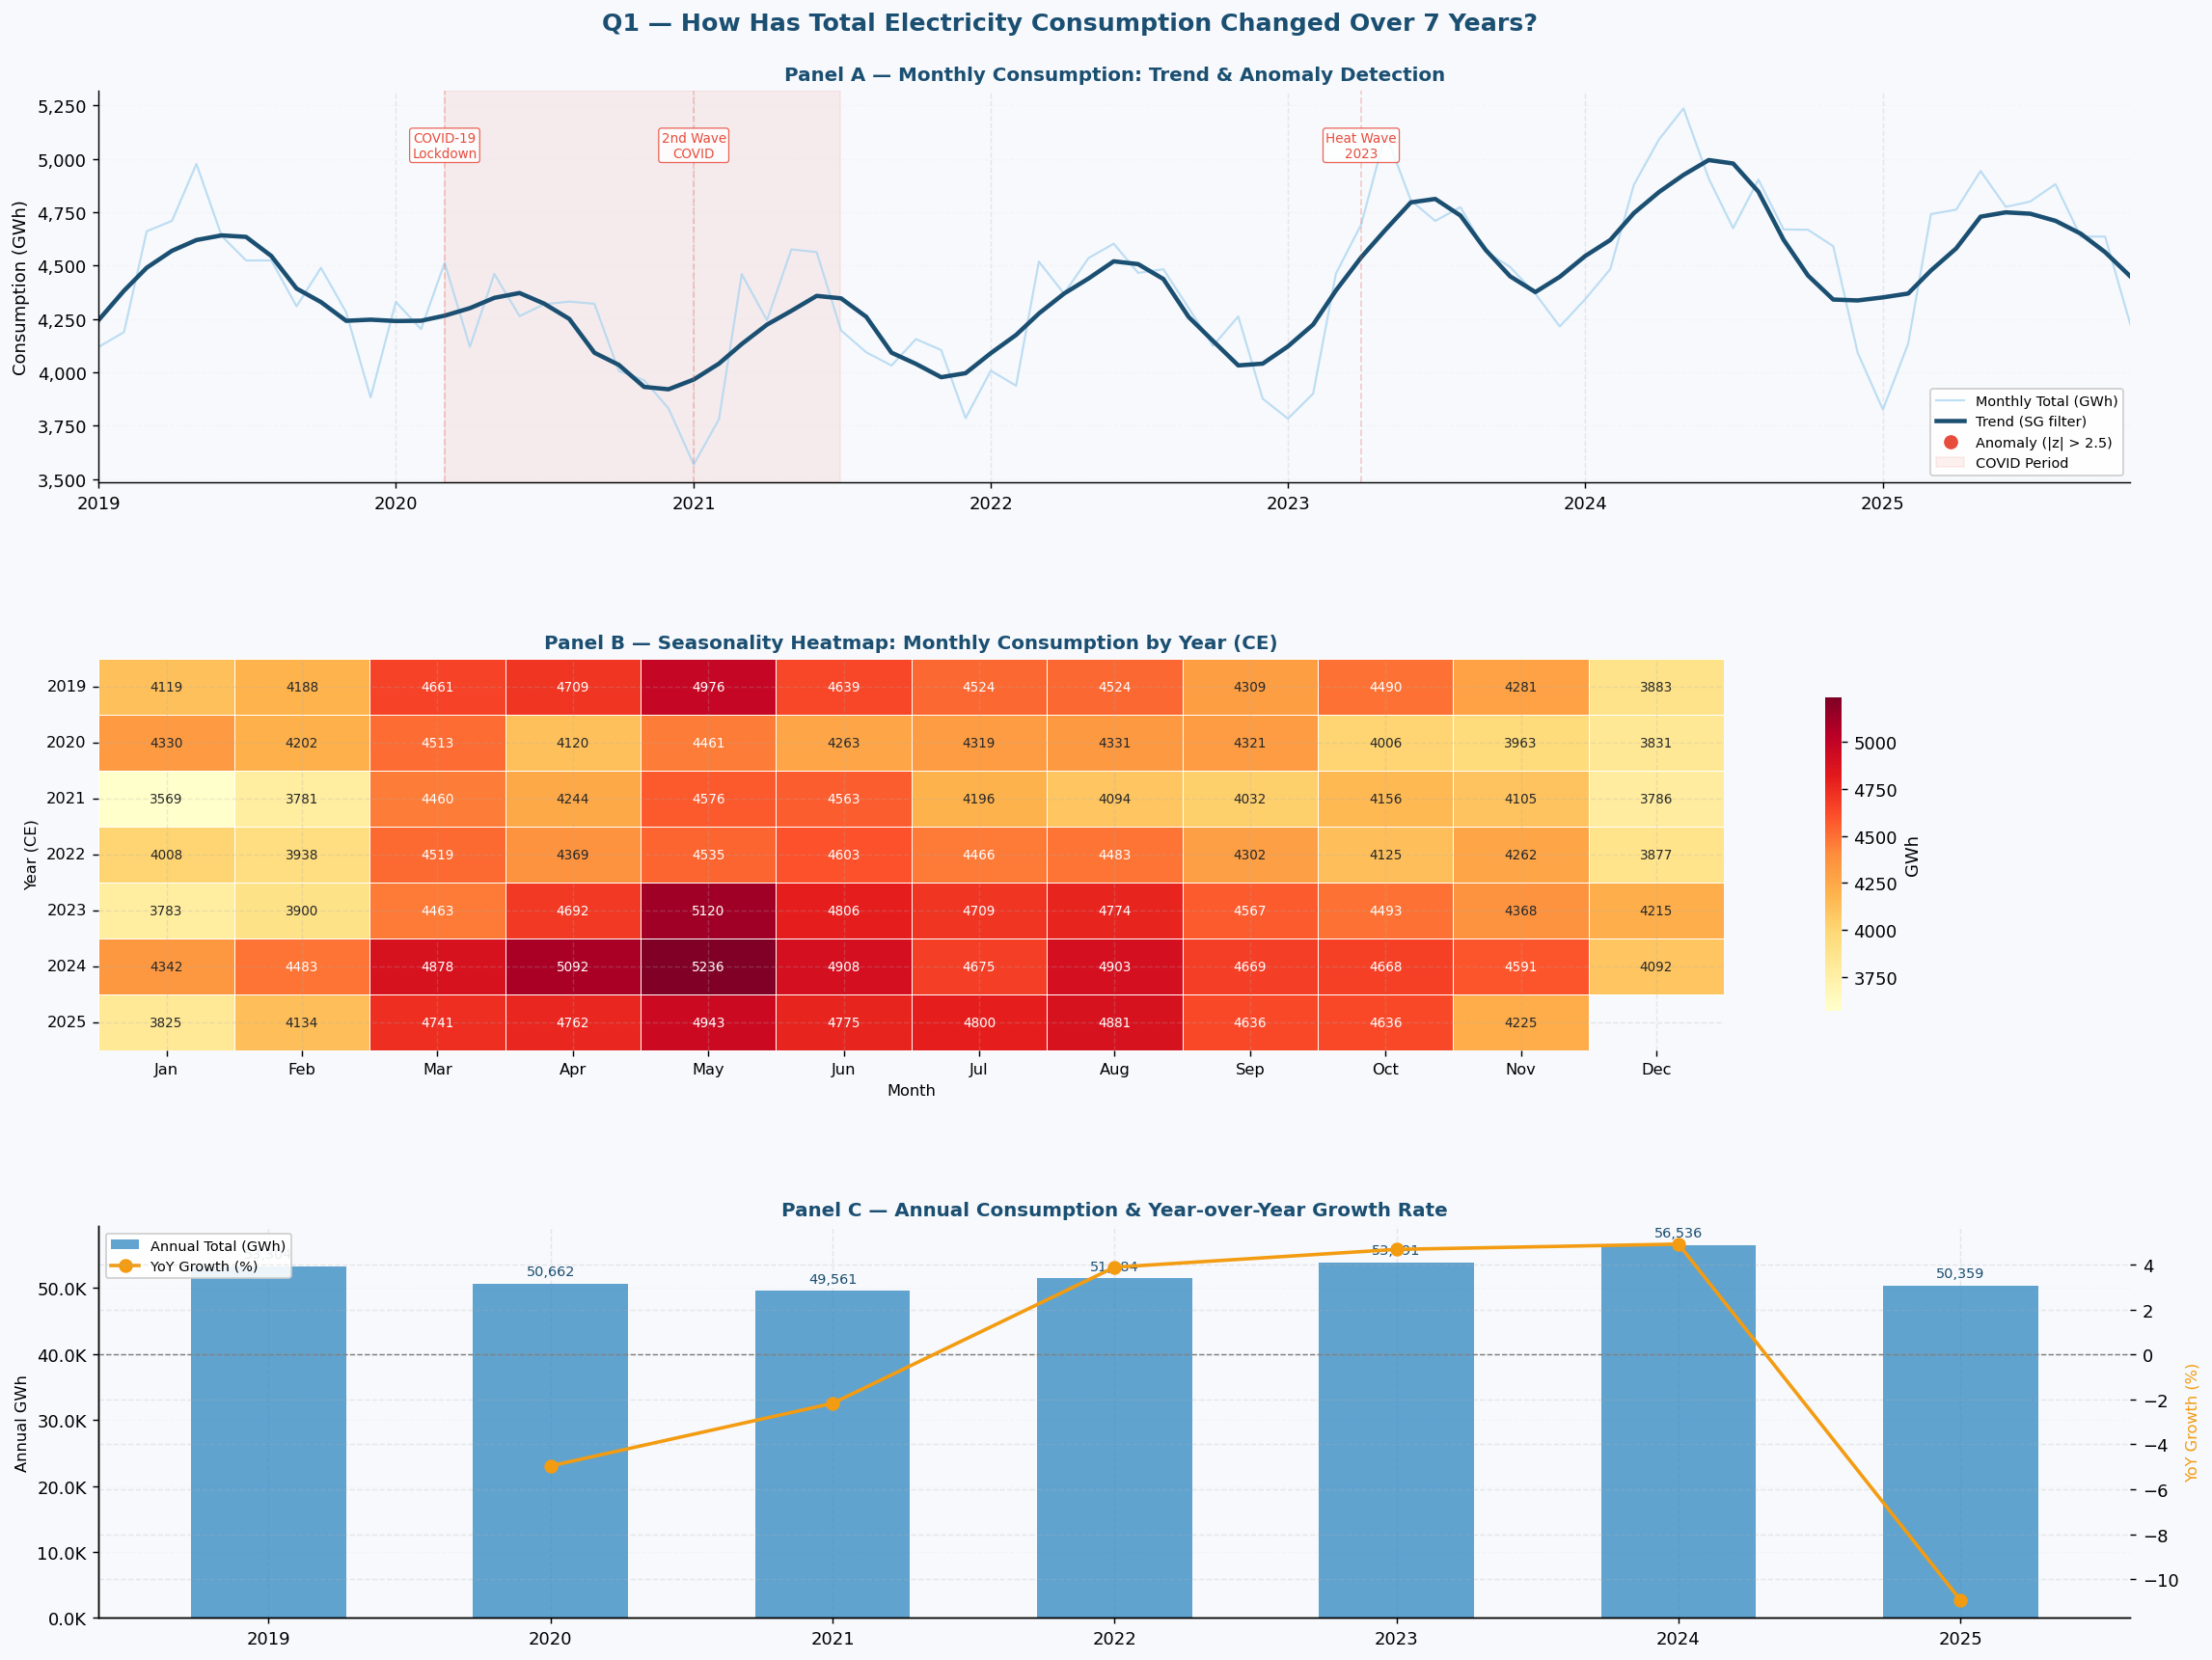

[SAVED] Q1_trend_anomaly.png

  💡  Q1 INSIGHTS — What / Why / Recommendation

สิ่งที่เกิดขึ้น
────
• ในช่วงระยะเวลา 7 ปี ปริมาณการใช้ไฟฟ้ารวมเพิ่มขึ้นจาก 53,304 GWh (2019)
   เป็น 50,359 GWh (2025 YTD);
   คิดเป็นการเปลี่ยนแปลงสุทธิประมาณ: -5.5%.
• โดยปีที่มีการลดลงมากที่สุดเมื่อเทียบกับปีก่อนหน้า (YoY) คือ ปี 2020 (-5.0%);
   หลังจากนั้นมีการฟื้นตัวใน 2021 (-2.2%).
• นอกจากนี้ยังพบรูปแบบตามฤดูกาลอย่างสม่ำเสมอ โดยช่วงที่มีการใช้ไฟฟ้าสูงสุดอยู่ใน Apr–May;
   ขณะที่ช่วงต่ำสุดมักเกิดใน Dec–Jan.

สาเหตุ
───
• การลดลงของการใช้ไฟฟ้าในปี 2020 เกิดจากมาตรการล็อกดาวน์ของ COVID-19 ในช่วงเดือนมีนาคมถึงมิถุนายน
   ซึ่งส่งผลให้โรงงาน สำนักงาน และโรงแรมจำนวนมากหยุดดำเนินงาน ทำให้โหลดไฟฟ้าลดลงประมาณ 10–15%
   เมื่อเทียบรายเดือน (MoM)
• การเพิ่มขึ้นในช่วง เมษายน–พฤษภาคม ปี 2023–2024 สอดคล้องกับช่วงคลื่นความร้อนในประเทศไทย
   ที่อุณหภูมิสูงถึง ≥40°C ส่งผลให้การใช้เครื่องปรับอากาศในภาคครัวเรือนเพิ่มขึ้นอย่างมาก
• หลังจากปี 2021 เป็นต้นมา การใช้ไฟฟ้าฟื้นตัวตามการเติบโตของเศรษฐกิจ
   การกลับมาของการท่องเท

In [ ]:
# ── Helper: deseasonalised Z-score anomaly detection ─────────────────────────

def detect_anomalies(series: pd.Series, z_thresh: float = 2.5) -> pd.Series:
    """
    Return boolean mask of anomalous months.
    Method: subtract monthly seasonal average → Z-score on residuals
            → flag |z| > z_thresh as anomaly.
    """
    s = series.copy()
    s.index = pd.to_datetime(s.index)
    month_avg = s.groupby(s.index.month).transform("mean")  # seasonal baseline
    residual  = s - month_avg
    z_scores  = np.abs(stats.zscore(residual.dropna()))
    anomaly   = pd.Series(False, index=residual.index)
    anomaly.iloc[
        residual.dropna().index.map(lambda x: residual.index.get_loc(x))
    ] = z_scores > z_thresh
    return anomaly


# ── Plot function ─────────────────────────────────────────────────────────────

def plot_q1_trend_anomaly(df: pd.DataFrame) -> None:
    """Q1 — Three-panel trend / seasonality / anomaly chart."""

    fig = plt.figure(figsize=(18, 14))
    fig.patch.set_facecolor(PALETTE["bg"])
    gs  = gridspec.GridSpec(3, 1, figure=fig, hspace=0.45,
                            left=0.07, right=0.97, top=0.93, bottom=0.06)

    total_series = df.set_index("date")["total_gwh"]

    # ── Panel A: Monthly line + trend + anomaly scatter ───────────────────────
    ax1 = fig.add_subplot(gs[0])
    ax1.set_facecolor(PALETTE["bg"])
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    # Raw monthly data
    ax1.plot(total_series.index, total_series.values,
             color=PALETTE["light_blue"], lw=1.2, alpha=0.8,
             label="Monthly Total (GWh)")

    # Savitzky-Golay smooth trend  (window=13 ≈ 1 year)
    trend = savgol_filter(total_series.values, window_length=13, polyorder=2)
    ax1.plot(total_series.index, trend,
             color=PALETTE["primary"], lw=2.5, label="Trend (SG filter)")

    # Anomaly scatter
    anomaly_mask = detect_anomalies(total_series)
    anomaly_pts  = total_series[anomaly_mask]
    ax1.scatter(anomaly_pts.index, anomaly_pts.values,
                color=PALETTE["accent"], zorder=5, s=80,
                label="Anomaly (|z| > 2.5)", edgecolors="white", lw=0.8)

    # Annotate known events (deduplicate by first-word key)
    annotated = set()
    for (yr, mo), label in KNOWN_EVENTS.items():
        mask = (df["year_ce"] == yr) & (df["month_en"] == mo)
        if mask.any():
            row = df[mask].iloc[0]
            key = label.split("\n")[0]
            if key not in annotated:
                ax1.axvline(row["date"], color=PALETTE["accent"],
                            alpha=0.25, lw=1, ls="--")
                ax1.text(row["date"], total_series.max() * 0.98,
                         label, fontsize=7.5, color=PALETTE["accent"],
                         ha="center", va="top",
                         bbox=dict(boxstyle="round,pad=0.2", fc="white",
                                   ec=PALETTE["accent"], alpha=0.85, lw=0.7))
                annotated.add(key)

    # COVID period shading
    ax1.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-30"),
                alpha=0.08, color=PALETTE["accent"], label="COVID Period")

    ax1.set_title("Panel A — Monthly Consumption: Trend & Anomaly Detection",
                  fontsize=11, fontweight="bold", color=PALETTE["primary"], pad=6)
    ax1.set_ylabel("Consumption (GWh)", fontsize=10)
    ax1.legend(loc="lower right", fontsize=8, framealpha=0.9)
    ax1.grid(axis="y", color=PALETTE["grid"], lw=0.7)
    ax1.set_xlim(total_series.index.min(), total_series.index.max())

    # ── Panel B: Seasonality heatmap ──────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1])
    ax2.set_facecolor(PALETTE["bg"])

    pivot = df.pivot_table(
        index="year_ce", columns="month_en",
        values="total_gwh", aggfunc="sum"
    )[MONTH_ORDER]

    sns.heatmap(pivot, ax=ax2, cmap="YlOrRd",
                annot=True, fmt=".0f", annot_kws={"size": 7.5},
                linewidths=0.4, linecolor="white",
                cbar_kws={"label": "GWh", "shrink": 0.8})
    ax2.set_title("Panel B — Seasonality Heatmap: Monthly Consumption by Year (CE)",
                  fontsize=11, fontweight="bold", color=PALETTE["primary"])
    ax2.set_xlabel("Month", fontsize=9)
    ax2.set_ylabel("Year (CE)", fontsize=9)
    ax2.tick_params(axis="x", rotation=0, labelsize=9)
    ax2.tick_params(axis="y", rotation=0, labelsize=9)

    # ── Panel C: Annual bar + YoY growth ──────────────────────────────────────
    ax3  = fig.add_subplot(gs[2])
    ax3b = ax3.twinx()
    ax3.set_facecolor(PALETTE["bg"])

    _annual = df.groupby("year_ce")["total_gwh"].sum()
    _years  = _annual.index.astype(str)
    _yoy    = _annual.pct_change() * 100

    bars = ax3.bar(_years, _annual.values, color=PALETTE["secondary"],
                   alpha=0.75, width=0.55, zorder=2, label="Annual Total (GWh)")
    ax3.bar_label(bars, fmt=lambda x: f"{x:,.0f}",
                  fontsize=8, padding=3, color=PALETTE["primary"])
    ax3b.plot(_years, _yoy.values, color=PALETTE["highlight"],
              marker="o", lw=2, ms=7, zorder=3, label="YoY Growth (%)")
    ax3b.axhline(0, color="gray", lw=0.8, ls="--")

    ax3.set_title("Panel C — Annual Consumption & Year-over-Year Growth Rate",
                  fontsize=11, fontweight="bold", color=PALETTE["primary"])
    ax3.set_ylabel("Annual GWh", fontsize=9)
    ax3b.set_ylabel("YoY Growth (%)", fontsize=9, color=PALETTE["highlight"])
    ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.1f}K"))
    ax3.grid(axis="y", color=PALETTE["grid"], lw=0.7, zorder=0)

    h1, l1 = ax3.get_legend_handles_labels()
    h2, l2 = ax3b.get_legend_handles_labels()
    ax3.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8, framealpha=0.9)

    fig.suptitle(
        "Q1 — How Has Total Electricity Consumption Changed Over 7 Years?",
        fontsize=14, fontweight="bold", color=PALETTE["primary"], y=0.975
    )
    plt.savefig("Q1_trend_anomaly.png", dpi=150,
                bbox_inches="tight", facecolor=PALETTE["bg"])
    plt.show()
    print("[SAVED] Q1_trend_anomaly.png")


# ── Run Q1 ────────────────────────────────────────────────────────────────────
plot_q1_trend_anomaly(df)

# ── Q1 Insights ───────────────────────────────────────────────────────────────
_a   = df.groupby("year_ce")["total_gwh"].sum()
_yoy = _a.pct_change() * 100

print("\n" + "=" * 65)
print("  💡  Q1 INSIGHTS — What / Why / Recommendation")
print("=" * 65)
print(textwrap.dedent(f"""
  สิ่งที่เกิดขึ้น
  ────
  • ในช่วงระยะเวลา 7 ปี ปริมาณการใช้ไฟฟ้ารวมเพิ่มขึ้นจาก {_a.iloc[0]:,.0f} GWh (2019)
     เป็น {_a.iloc[-1]:,.0f} GWh (2025 YTD);
     คิดเป็นการเปลี่ยนแปลงสุทธิประมาณ: {((_a.iloc[-1]/_a.iloc[0])-1)*100:+.1f}%.
  • โดยปีที่มีการลดลงมากที่สุดเมื่อเทียบกับปีก่อนหน้า (YoY) คือ ปี 2020 ({_yoy[2020]:+.1f}%);
     หลังจากนั้นมีการฟื้นตัวใน 2021 ({_yoy[2021]:+.1f}%).
  • นอกจากนี้ยังพบรูปแบบตามฤดูกาลอย่างสม่ำเสมอ โดยช่วงที่มีการใช้ไฟฟ้าสูงสุดอยู่ใน Apr–May;
     ขณะที่ช่วงต่ำสุดมักเกิดใน Dec–Jan.

  สาเหตุ
  ───
  • การลดลงของการใช้ไฟฟ้าในปี 2020 เกิดจากมาตรการล็อกดาวน์ของ COVID-19 ในช่วงเดือนมีนาคมถึงมิถุนายน
     ซึ่งส่งผลให้โรงงาน สำนักงาน และโรงแรมจำนวนมากหยุดดำเนินงาน ทำให้โหลดไฟฟ้าลดลงประมาณ 10–15%
     เมื่อเทียบรายเดือน (MoM)
  • การเพิ่มขึ้นในช่วง เมษายน–พฤษภาคม ปี 2023–2024 สอดคล้องกับช่วงคลื่นความร้อนในประเทศไทย
     ที่อุณหภูมิสูงถึง ≥40°C ส่งผลให้การใช้เครื่องปรับอากาศในภาคครัวเรือนเพิ่มขึ้นอย่างมาก
  • หลังจากปี 2021 เป็นต้นมา การใช้ไฟฟ้าฟื้นตัวตามการเติบโตของเศรษฐกิจ
     การกลับมาของการท่องเที่ยว และกิจกรรมการผลิตในภาคอุตสาหกรรม

  ข้อเสนอแนะเชิงปฏิบัติ
  ──────────────────────────
  1. เสริมความยืดหยุ่นของระบบไฟฟ้า (Grid Resilience) — พัฒนาโปรแกรม Demand Response
     ในช่วงเดือนเมษายน–พฤษภาคม และสนับสนุนการใช้พลังงานนอกช่วงพีค
     เช่น ระบบทำความเย็นแบบกักเก็บน้ำแข็ง (Ice Storage)
  2. การตรวจจับความผิดปกติของข้อมูล (Anomaly Monitoring) — พัฒนาระบบ Z-score monitoring
     อัตโนมัติ เพื่อใช้เป็นแดชบอร์ดแจ้งเตือนแบบเรียลไทม์สำหรับการปฏิบัติการระบบไฟฟ้า
  3. การวางแผนเชิงสถานการณ์ (Scenario Planning) — สร้างแบบจำลองความต้องการไฟฟ้าในกรณี
     ปีที่เกิดคลื่นความร้อนรุนแรง เทียบกับ ปีที่อากาศไม่รุนแรง เพื่อเตรียมกำลังการผลิตและสำรองไฟฟ้าให้เพียงพอล่วงหน้า
"""))


#🏙 Question 2 — District Ranking & Growth

เหตุผลของการใช้ Bubble Chart คือเพื่อแสดงข้อมูลเชิงปริมาณหลายมิติในกราฟเดียว โดยแกน X-axis แสดงปริมาณการใช้ไฟฟ้ารวมในช่วง 7 ปี (Total Consumption) เพื่อสะท้อนขนาดของการใช้พลังงานในแต่ละเขต ส่วน Y-axis แสดงอัตราการเติบโตเฉลี่ยต่อปี หรือ CAGR ระหว่างปี 2019–2025 เพื่อให้เห็นแนวโน้มการเติบโตของแต่ละพื้นที่ ขณะที่ ขนาดของ Bubble ใช้แทนค่าเฉลี่ยการใช้ไฟฟ้ารายเดือน เพื่อบ่งบอกระดับขนาดการใช้พลังงานโดยรวม และ สีของ Bubble ใช้แบ่งกลุ่มเชิงกลยุทธ์ (Strategic Quadrant) ของแต่ละเขต การใช้กราฟลักษณะนี้ช่วยให้สามารถจำแนกทั้ง 18 เขตออกเป็นกลุ่มต่าง ๆ ได้อย่างรวดเร็วในภาพเดียว ซึ่งกราฟแท่งทั่วไปไม่สามารถแสดงความสัมพันธ์ของหลายมิติได้พร้อมกัน

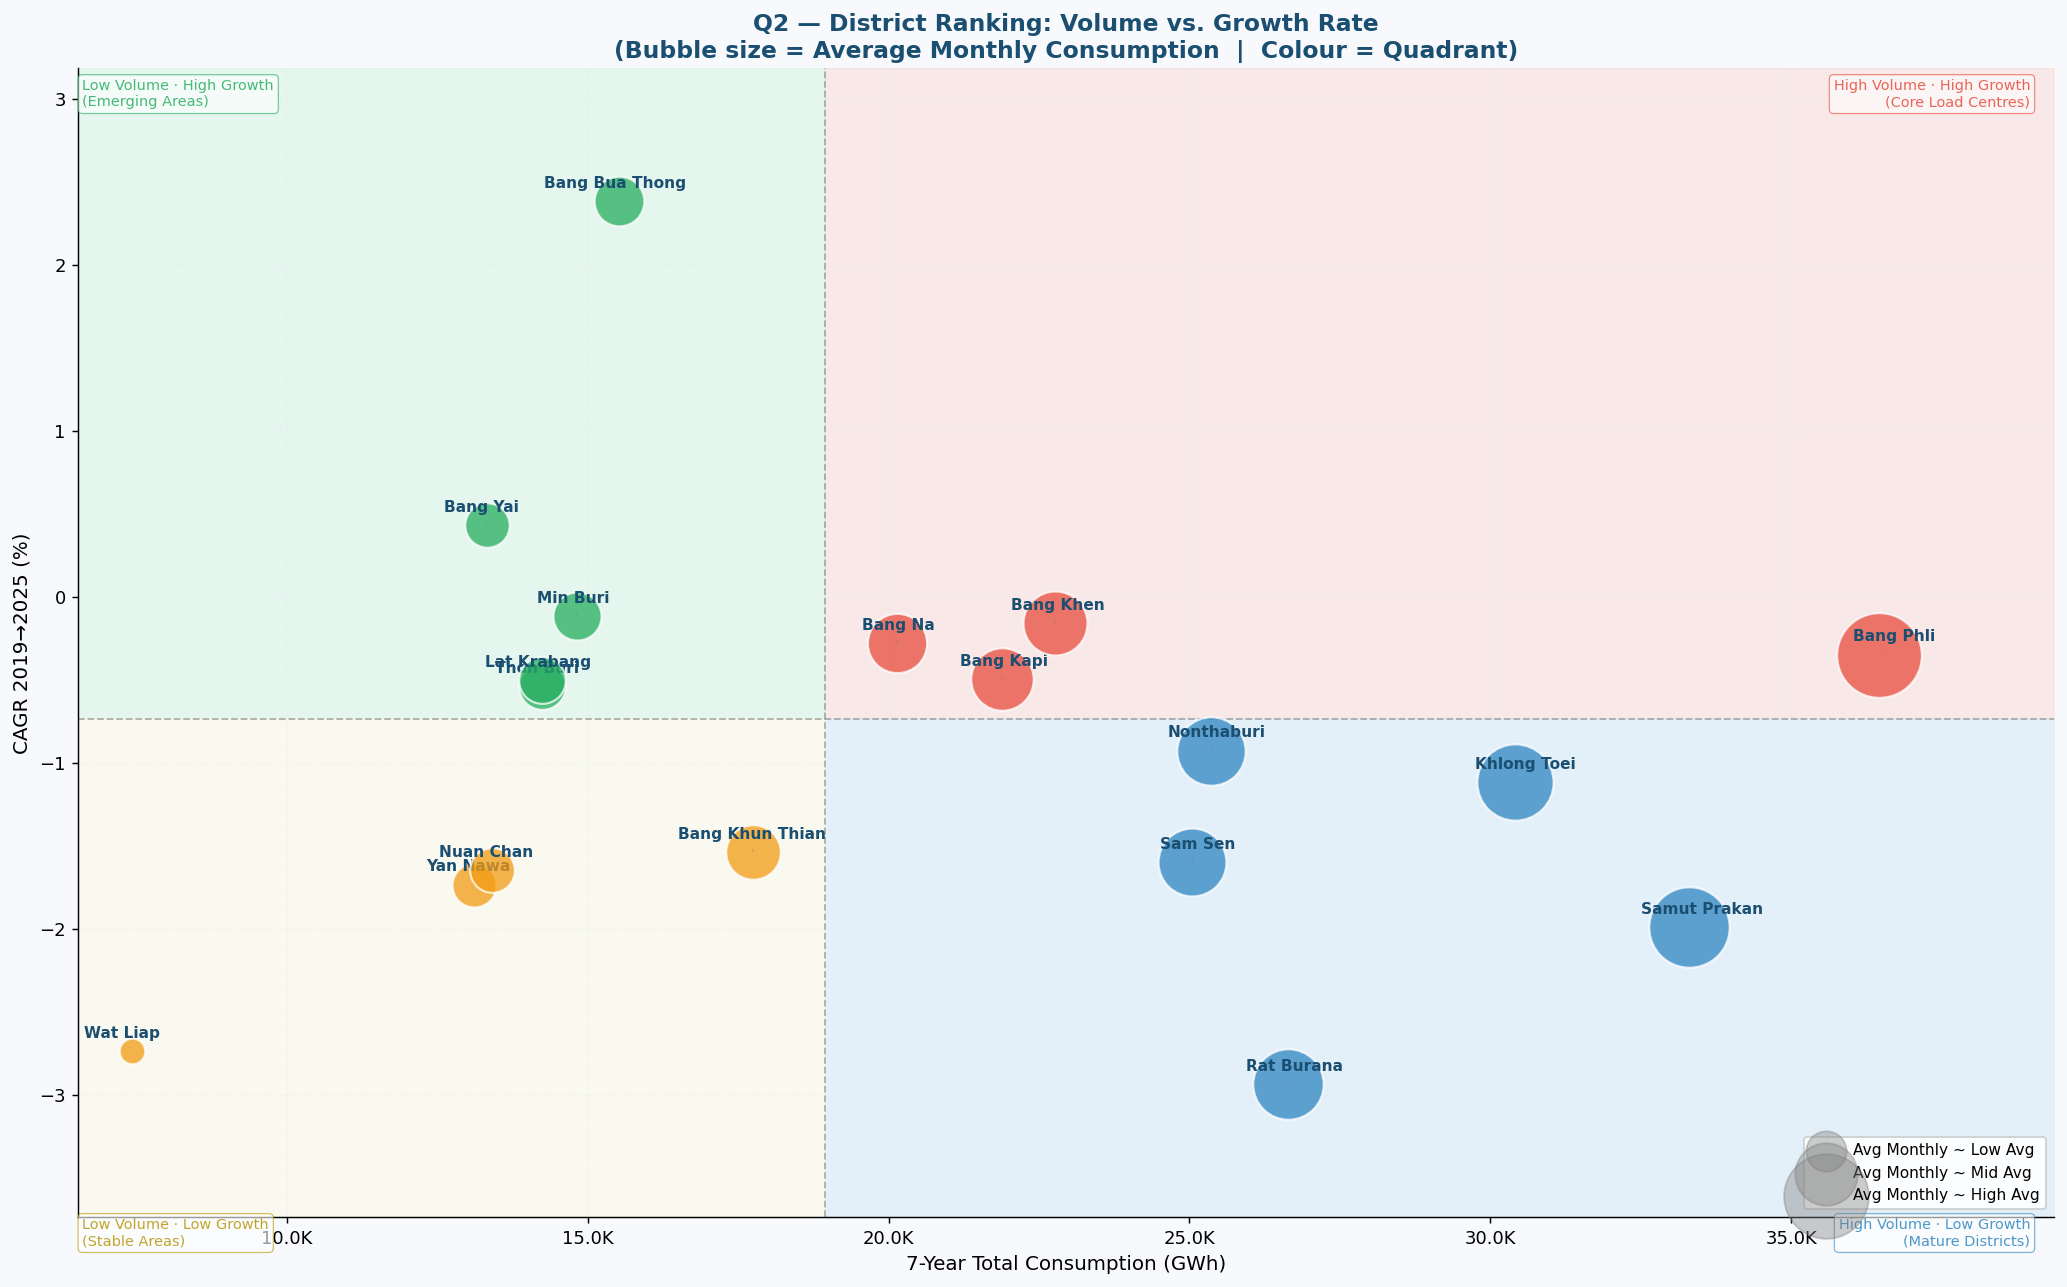

[SAVED] Q2_district_ranking.png

  💡  Q2 INSIGHTS — What / Why / Recommendation

สิ่งที่พบจากข้อมูล
────
• จากการวิเคราะห์ข้อมูลการใช้ไฟฟ้าในช่วง 7 ปี พบว่าเขตที่มีปริมาณการใช้ไฟฟ้ารวมสูงที่สุด ได้แก่ :
    Bang Phli, Samut Prakan, Khlong Toei
• ขณะที่เขตที่มีอัตราการเติบโตเร็วที่สุด (CAGR ระหว่างปี 2019–2025) คือ :
    Bang Bua Thong, Bang Yai, Min Buri
• โดยช่วงของอัตราการเติบโตเฉลี่ยต่อปีอยู่ระหว่างประมาณ: -2.93% (เติบโตต่ำสุด)
                                            → 2.39% (เติบโตสูงสุด).

สาเหตุ
───
• เขต Bang Phli และ Samut Prakan เป็นพื้นที่สำคัญของเขตอุตสาหกรรมฝั่งตะวันออก
    (Eastern Industrial Corridor) ซึ่งมีโรงงานและศูนย์โลจิสติกส์จำนวนมาก จึงทำให้มีการใช้ไฟฟ้าในปริมาณสูง
• ส่วนเขตชานเมืองที่มีการเติบโตสูง เช่น Bang Yai และ Bang Bua Thong
    สะท้อนการขยายตัวของกรุงเทพมหานครและปริมณฑล โดยมีโครงการที่อยู่อาศัยใหม่ ศูนย์ข้อมูล (Data Centers)
• ศูนย์การค้าเพิ่มขึ้น ในขณะที่เขตใจกลางเมืองบางแห่ง เช่น Wat Liap มีอัตราการเติบโตต่ำ
    เนื่องจากเป็นพื้นที่เมืองที่พัฒนาเต็มที

In [ ]:
def plot_q2_district_ranking(df: pd.DataFrame,
                             district_cols: list[str]) -> None:
    """Q2 — Bubble chart: 7-year volume vs. CAGR, sized by avg monthly load."""

    # ── Compute per-district metrics ──────────────────────────────────────────
    d_total = df[district_cols].sum()
    d_avg   = df[district_cols].mean()

    fy   = df[df["year_ce"] == df["year_ce"].min()][district_cols].sum()
    ly   = df[df["year_ce"] == df["year_ce"].max()][district_cols].sum()
    ny   = df["year_ce"].max() - df["year_ce"].min()
    cagr = ((ly / fy) ** (1 / ny) - 1) * 100

    metrics = pd.DataFrame({"total": d_total, "avg": d_avg, "cagr": cagr})
    med_x = metrics["total"].median()
    med_y = metrics["cagr"].median()

    # ── Quadrant classification ───────────────────────────────────────────────
    def quadrant(row):
        if row["total"] >= med_x and row["cagr"] >= med_y:
            return "High Volume · High Growth",  "#E74C3C"
        elif row["total"] >= med_x and row["cagr"] < med_y:
            return "High Volume · Low Growth",   "#2E86C1"
        elif row["total"] < med_x and row["cagr"] >= med_y:
            return "Low Volume · High Growth",   "#27AE60"
        else:
            return "Low Volume · Low Growth",    "#F39C12"

    metrics[["quad_label", "quad_color"]] = pd.DataFrame(
        metrics.apply(quadrant, axis=1).tolist(), index=metrics.index
    )

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(16, 10))
    fig.patch.set_facecolor(PALETTE["bg"])
    ax.set_facecolor(PALETTE["bg"])

    xlim = (metrics["total"].min() * 0.88, metrics["total"].max() * 1.08)
    ylim = (metrics["cagr"].min() - 0.8,   metrics["cagr"].max() + 0.8)

    # Quadrant background shading
    for x0, x1, y0, y1, col in [
        (med_x, xlim[1], med_y, ylim[1], "#FADBD8"),
        (xlim[0], med_x, med_y, ylim[1], "#D5F5E3"),
        (med_x, xlim[1], ylim[0], med_y, "#D6EAF8"),
        (xlim[0], med_x, ylim[0], med_y, "#FEF9E7"),
    ]:
        ax.fill_between([x0, x1], [y0, y0], [y1, y1],
                        color=col, alpha=0.55, zorder=0)

    ax.axvline(med_x, color="gray", ls="--", lw=1, alpha=0.6)
    ax.axhline(med_y, color="gray", ls="--", lw=1, alpha=0.6)

    # Bubble size scaled from avg monthly consumption
    bubble_size = (
        (metrics["avg"] - metrics["avg"].min()) /
        (metrics["avg"].max() - metrics["avg"].min()) * 2000 + 200
    )

    # Plot each district
    for dist, row in metrics.iterrows():
        ax.scatter(row["total"], row["cagr"],
                   s=bubble_size[dist], color=row["quad_color"],
                   alpha=0.75, edgecolors="white", lw=1.2, zorder=3)
        offset_x = (row["total"] - med_x) * 0.015
        ax.annotate(
            dist,
            xy=(row["total"], row["cagr"]),
            xytext=(row["total"] + offset_x, row["cagr"] + 0.08),
            fontsize=8.5, fontweight="bold", color=PALETTE["primary"],
            ha="center",
            arrowprops=dict(arrowstyle="-", color="gray", lw=0.5, alpha=0.5),
        )

    # Quadrant corner labels
    for xp, yp, lbl, col, ha, va in [
        (xlim[1]*0.99, ylim[1]*0.98,
         "High Volume · High Growth\n(Core Load Centres)",  "#E74C3C", "right", "top"),
        (xlim[0]*1.01, ylim[1]*0.98,
         "Low Volume · High Growth\n(Emerging Areas)",      "#27AE60", "left",  "top"),
        (xlim[1]*0.99, ylim[0]*1.05,
         "High Volume · Low Growth\n(Mature Districts)",    "#2E86C1", "right", "bottom"),
        (xlim[0]*1.01, ylim[0]*1.05,
         "Low Volume · Low Growth\n(Stable Areas)",         "#B7950B", "left",  "bottom"),
    ]:
        ax.text(xp, yp, lbl, fontsize=8, color=col, ha=ha, va=va, alpha=0.85,
                bbox=dict(boxstyle="round,pad=0.3", fc="white",
                          ec=col, alpha=0.6, lw=0.7))

    # Bubble size legend
    for sv, lbl in [(500, "Low Avg"), (1200, "Mid Avg"), (2200, "High Avg")]:
        ax.scatter([], [], s=sv, color="gray", alpha=0.4,
                   label=f"Avg Monthly ~ {lbl}")

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel("7-Year Total Consumption (GWh)", fontsize=11)
    ax.set_ylabel("CAGR 2019→2025 (%)", fontsize=11)
    ax.set_title(
        "Q2 — District Ranking: Volume vs. Growth Rate\n"
        "(Bubble size = Average Monthly Consumption  |  Colour = Quadrant)",
        fontsize=13, fontweight="bold", color=PALETTE["primary"]
    )
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1000:.1f}K"))
    ax.legend(loc="lower right", fontsize=8.5, framealpha=0.9)
    ax.grid(color=PALETTE["grid"], lw=0.6, zorder=0)

    plt.tight_layout()
    plt.savefig("Q2_district_ranking.png", dpi=150,
                bbox_inches="tight", facecolor=PALETTE["bg"])
    plt.show()
    print("[SAVED] Q2_district_ranking.png")


# ── Run Q2 ────────────────────────────────────────────────────────────────────
plot_q2_district_ranking(df, district_cols)

# ── Q2 Insights ───────────────────────────────────────────────────────────────
_top3_vol  = dist_total.head(3).index.tolist()
_top3_grow = dist_cagr.sort_values(ascending=False).head(3).index.tolist()

print("\n" + "=" * 65)
print("  💡  Q2 INSIGHTS — What / Why / Recommendation")
print("=" * 65)
print(textwrap.dedent(f"""
  สิ่งที่พบจากข้อมูล
  ────
  • จากการวิเคราะห์ข้อมูลการใช้ไฟฟ้าในช่วง 7 ปี พบว่าเขตที่มีปริมาณการใช้ไฟฟ้ารวมสูงที่สุด ได้แก่ :
      {', '.join(_top3_vol)}
  • ขณะที่เขตที่มีอัตราการเติบโตเร็วที่สุด (CAGR ระหว่างปี 2019–2025) คือ :
      {', '.join(_top3_grow)}
  • โดยช่วงของอัตราการเติบโตเฉลี่ยต่อปีอยู่ระหว่างประมาณ: {dist_cagr.min():.2f}% (เติบโตต่ำสุด)
                                              → {dist_cagr.max():.2f}% (เติบโตสูงสุด).

  สาเหตุ
  ───
  • เขต Bang Phli และ Samut Prakan เป็นพื้นที่สำคัญของเขตอุตสาหกรรมฝั่งตะวันออก
      (Eastern Industrial Corridor) ซึ่งมีโรงงานและศูนย์โลจิสติกส์จำนวนมาก จึงทำให้มีการใช้ไฟฟ้าในปริมาณสูง
  • ส่วนเขตชานเมืองที่มีการเติบโตสูง เช่น Bang Yai และ Bang Bua Thong
      สะท้อนการขยายตัวของกรุงเทพมหานครและปริมณฑล โดยมีโครงการที่อยู่อาศัยใหม่ ศูนย์ข้อมูล (Data Centers)
  • ศูนย์การค้าเพิ่มขึ้น ในขณะที่เขตใจกลางเมืองบางแห่ง เช่น Wat Liap มีอัตราการเติบโตต่ำ
      เนื่องจากเป็นพื้นที่เมืองที่พัฒนาเต็มที่แล้วและมีโครงการก่อสร้างใหม่ค่อนข้างจำกัด

  ข้อเสนอแนะเชิงปฏิบัติ
  ──────────────────────────
  1. การลงทุนโครงสร้างพื้นฐานไฟฟ้า (Capacity Investment) — ควรเร่งปรับปรุงหรือขยายสถานีไฟฟ้า
      ย่อยในเขตที่มี ปริมาณใช้ไฟฟ้าปัจจุบันต่ำแต่เติบโตสูง เพื่อรองรับความต้องการไฟฟ้าที่เพิ่มขึ้นในอนาคต
  2. Eการเพิ่มประสิทธิภาพพลังงาน (Energy Efficiency) — ดำเนินโครงการตรวจสอบการใช้พลังงาน
      สำหรับลูกค้ารายใหญ่ในเขตที่มี ปริมาณใช้ไฟฟ้าสูงแต่การเติบโตต่ำ เพื่อลดการใช้พลังงานรวม (MWh)
  3. การพยากรณ์ความต้องการไฟฟ้า (Demand Forecasting) — ใช้อัตราการเติบโต CAGR ของ
      แต่ละเขต เป็นตัวแปรน้ำหนัก (input weight) ในการสร้างแบบจำลองพยากรณ์ความต้องการไฟฟ้า
      ระดับจังหวัดในช่วง 5 ปีข้างหน้า เพื่อเพิ่มความแม่นยำในการวางแผนระบบไฟฟ้า
"""))



#🌦 Question 3 — Seasonal Patterns by District

เหตุผลของการออกแบบกราฟ (Chart Rationale) นี้คือการใช้ รูปแบบกราฟสามส่วน (Three-panel layout) เพื่อช่วยตอบคำถามว่า “เขตใดมีรูปแบบการใช้ไฟฟ้าตามฤดูกาลมากที่สุด” จากหลายมุมมองพร้อมกัน โดย Panel A แสดงกราฟย่อยหลายกราฟ (small multiples) จัดเป็นตาราง 6×3 สำหรับแต่ละเขต โดยปรับข้อมูลให้อยู่ในรูปแบบ normalized seasonal profile และมีการระบุเดือนที่มีค่าสูงสุด เพื่อให้สามารถเปรียบเทียบรูปแบบการเปลี่ยนแปลงของแต่ละเขตแบบดูเคียงกันได้อย่างชัดเจน ส่วน Panel B เป็นกราฟแท่งที่แสดงค่า Coefficient of Variation (σ/μ × 100) เพื่อจัดอันดับระดับความผันผวนของการใช้ไฟฟ้าในแต่ละเขต และ Panel C เป็น heatmap ของเขตเทียบกับเดือน ที่แสดงค่าความเบี่ยงเบนเป็นเปอร์เซ็นต์ในแต่ละช่อง ทำให้เห็นขนาดการเปลี่ยนแปลงของการใช้ไฟฟ้าในแต่ละเดือนของแต่ละเขตได้อย่างละเอียดในภาพเดียว

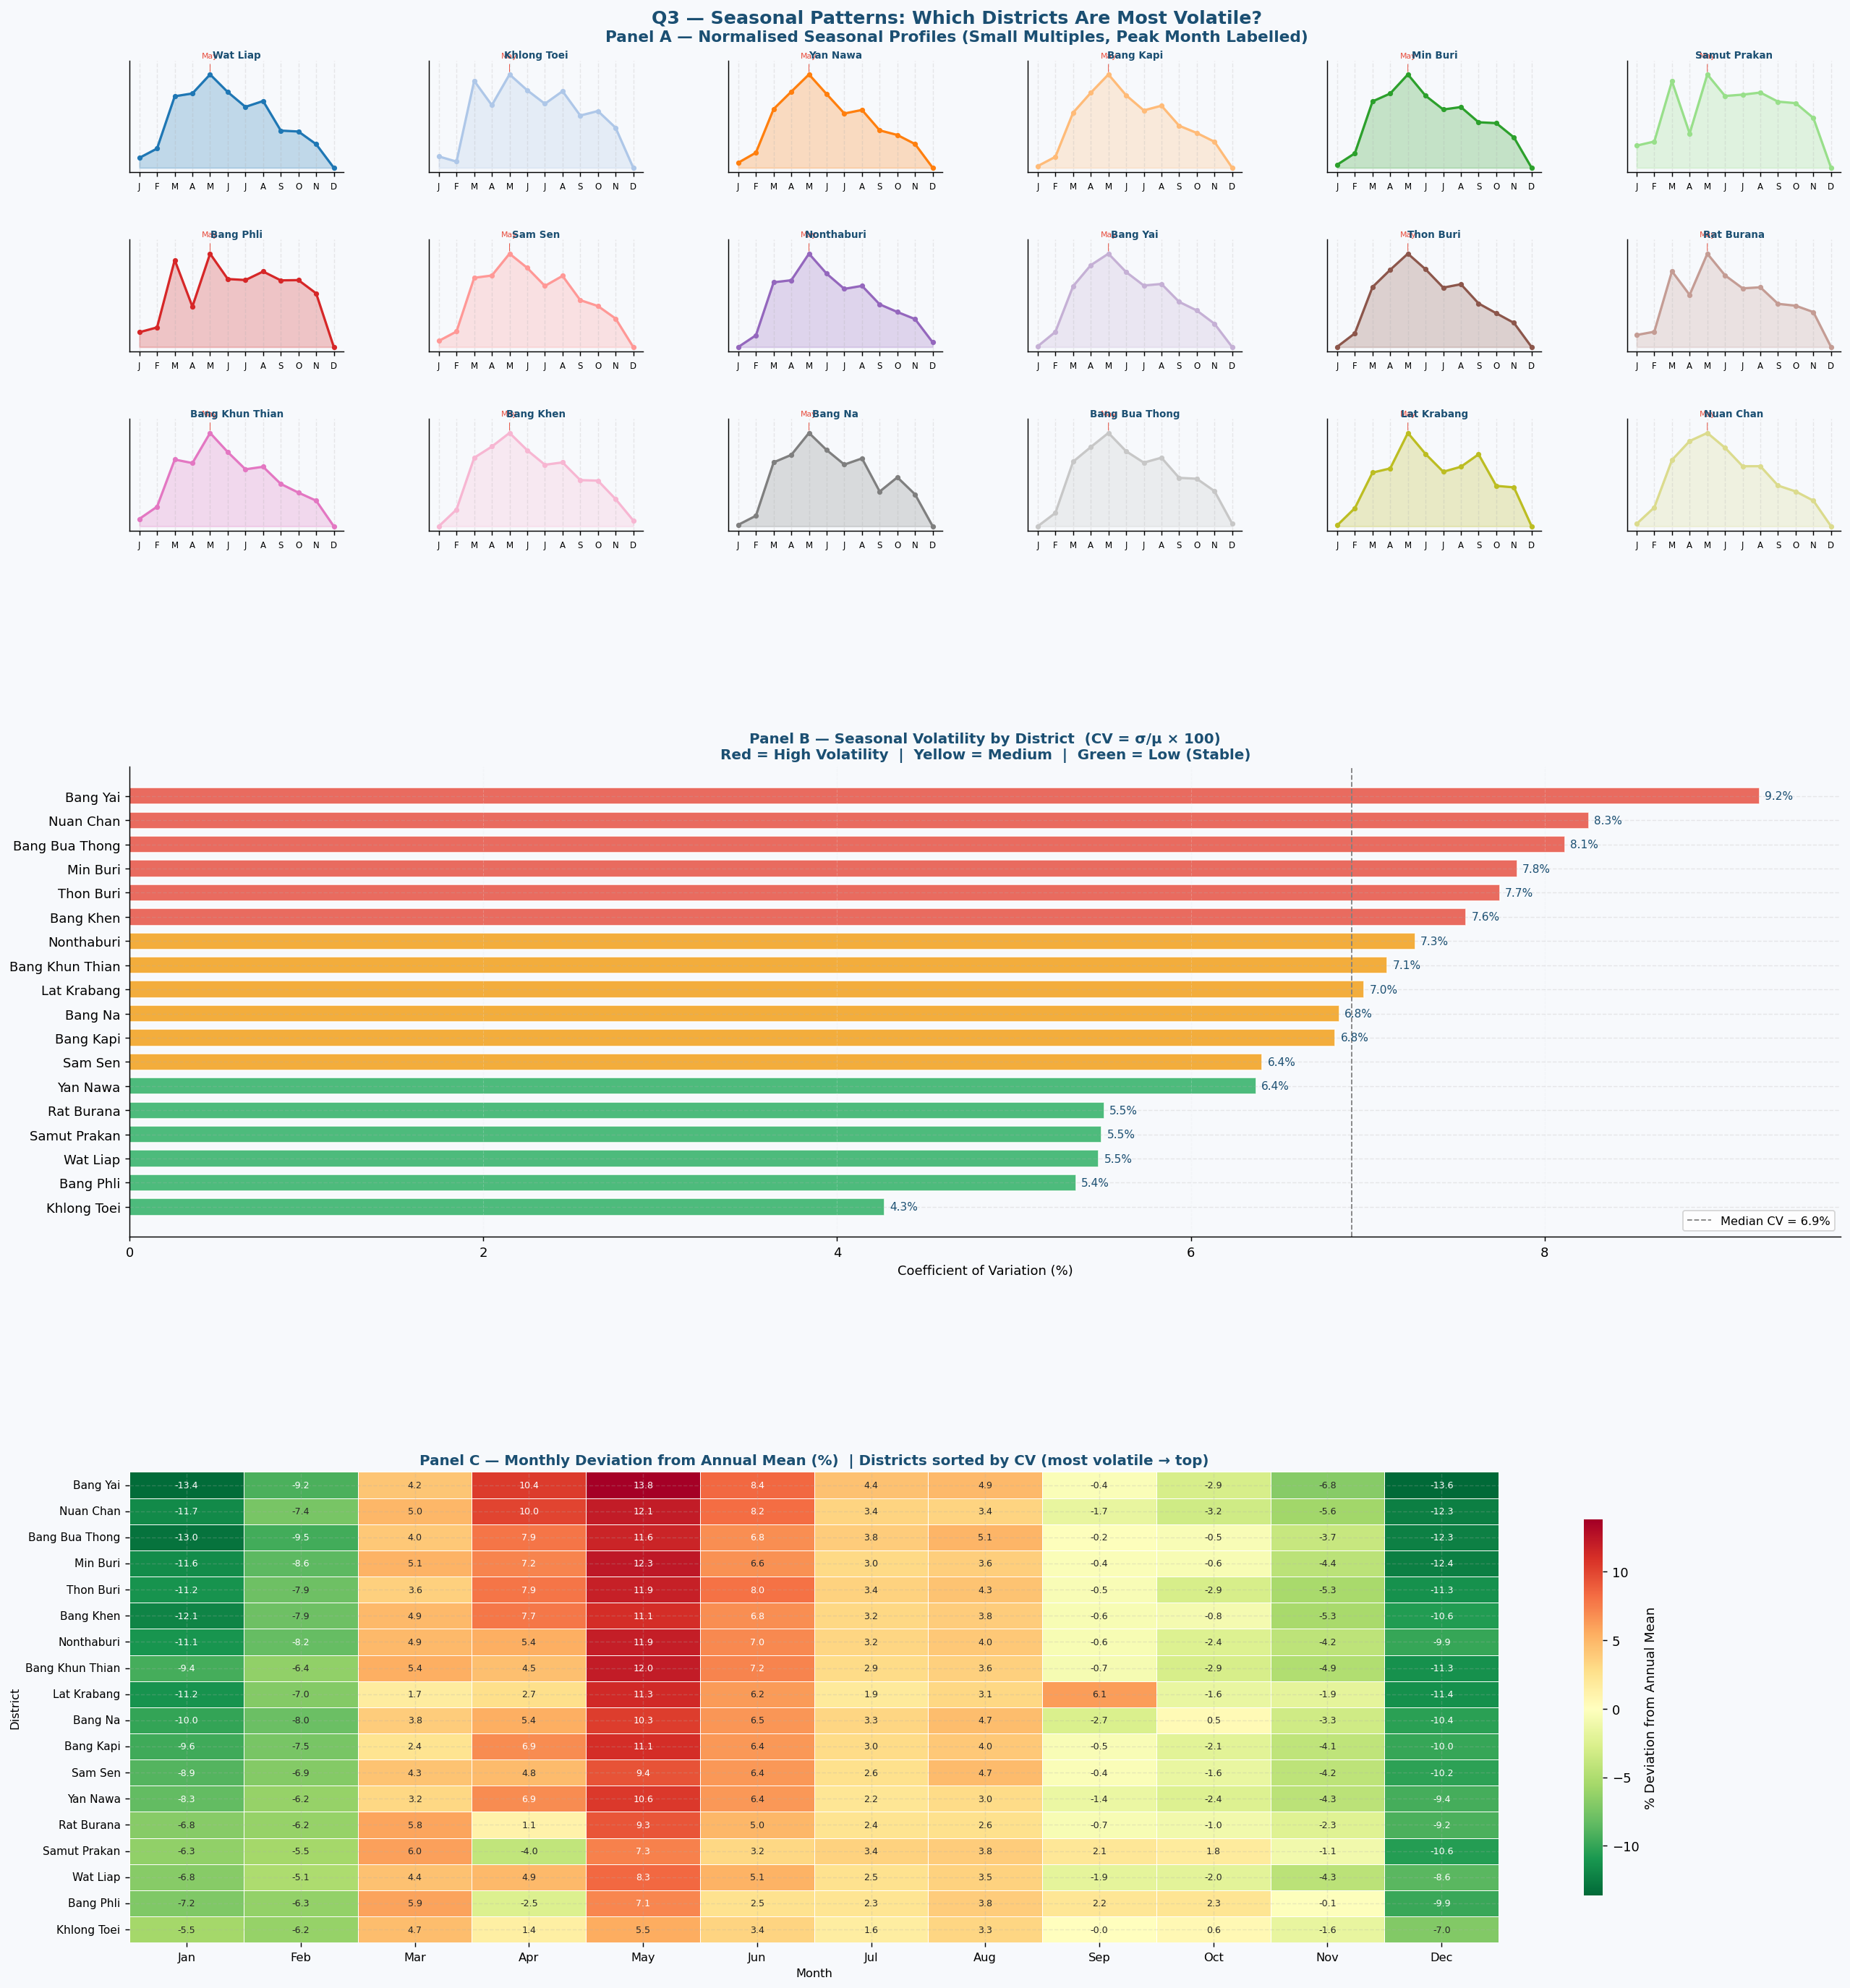

[SAVED] Q3_seasonal_patterns.png

  💡  Q3 INSIGHTS — What / Why / Recommendation

สิ่งที่พบจากข้อมูล
────
จากการวิเคราะห์ความผันผวนตามฤดูกาลของการใช้ไฟฟ้า พบว่าเขตที่มีความผันผวนสูงที่สุด
(ค่า Coefficient of Variation – CV สูง) ได้แก่ Bang Yai, Nuan Chan, Bang Bua Thong
ซึ่งมีการเปลี่ยนแปลงของการใช้ไฟฟ้าประมาณ ≥ 9.2% เมื่อเทียบกับค่าเฉลี่ยรายปี
ขณะที่เขตที่มีความเสถียรตลอดทั้งปี (ค่า CV ต่ำ) ได้แก่ Wat Liap, Bang Phli, Khlong Toei
ซึ่งมีรูปแบบการใช้ไฟฟ้าที่ค่อนข้างคงที่ ไม่เปลี่ยนแปลงมากตามเดือน

WHY
───
เขตที่มีค่า CV สูง ส่วนใหญ่มักเป็นพื้นที่ที่อยู่อาศัยหรือพื้นที่ผสม (residential/mixed-use)
ซึ่งการใช้ไฟฟ้ามีความสัมพันธ์กับอุณหภูมิภายนอกและการใช้เครื่องปรับอากาศ ทำให้เกิดจุดสูงสุดของ
การใช้ไฟฟ้าในช่วงฤดูร้อน และลดลงในช่วงอากาศเย็น ในทางตรงกันข้าม เขตที่มีค่า CV ต่ำ มักมี
ภาคอุตสาหกรรมหรือศูนย์ข้อมูล (data center) ที่ใช้ไฟฟ้าตลอด 24 ชั่วโมง จึงไม่ได้รับผลกระทบ
จากฤดูกาลมากนัก สำหรับเขตที่มีลักษณะผสม เช่น Khlong Toei ซึ่งมีทั้งสำนักงานและที่อยู่อาศัย
จะมีค่า CV ระดับปานกลาง เนื่องจากก

In [ ]:
def plot_q3_seasonal_patterns(df: pd.DataFrame,
                              district_cols: list[str]) -> None:
    """Q3 — Seasonal profiles, CV ranking, and deviation heatmap."""

    # ── Pre-compute ───────────────────────────────────────────────────────────
    m_mean = df.groupby("month_en")[district_cols].mean().reindex(MONTH_ORDER)

    # Normalised profiles [0, 1] for shape comparison
    norm = ((m_mean - m_mean.min()) / (m_mean.max() - m_mean.min()))

    # Coefficient of Variation
    cv = (m_mean.std() / m_mean.mean() * 100).sort_values(ascending=False)

    # % deviation from each district's annual mean
    deviation = ((m_mean - m_mean.mean()) / m_mean.mean() * 100)

    # ── Figure layout ─────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(20, 22))
    fig.patch.set_facecolor(PALETTE["bg"])
    outer = gridspec.GridSpec(3, 1, figure=fig, hspace=0.5,
                              top=0.95, bottom=0.04, left=0.06, right=0.97)

    # ── Panel A: Small multiples (6 cols × 3 rows) ────────────────────────────
    inner_a = gridspec.GridSpecFromSubplotSpec(
        3, 6, subplot_spec=outer[0], hspace=0.6, wspace=0.4
    )
    for idx, dist in enumerate(district_cols):
        r, c = divmod(idx, 6)
        ax = fig.add_subplot(inner_a[r, c])
        ax.set_facecolor(PALETTE["bg"])
        color = DISTRICT_COLORS[idx]

        ax.fill_between(range(12), norm[dist].values, alpha=0.25, color=color)
        ax.plot(range(12), norm[dist].values, color=color, lw=1.8,
                marker="o", ms=3)
        ax.set_xticks(range(12))
        ax.set_xticklabels(
            ["J","F","M","A","M","J","J","A","S","O","N","D"], fontsize=6.5
        )
        ax.set_yticks([])
        ax.set_ylim(-0.05, 1.15)
        ax.set_title(dist, fontsize=7.5, fontweight="bold",
                     color=PALETTE["primary"], pad=2)

        # Annotate peak month
        peak_idx = norm[dist].values.argmax()
        ax.annotate(
            MONTH_ORDER[peak_idx],
            xy=(peak_idx, norm[dist].values[peak_idx]),
            xytext=(peak_idx, norm[dist].values[peak_idx] + 0.18),
            fontsize=6, color=PALETTE["accent"], ha="center",
            arrowprops=dict(arrowstyle="-", color=PALETTE["accent"], lw=0.5)
        )

    fig.text(0.5, 0.965,
             "Panel A — Normalised Seasonal Profiles (Small Multiples, Peak Month Labelled)",
             ha="center", va="top", fontsize=12,
             fontweight="bold", color=PALETTE["primary"])

    # ── Panel B: CV bar chart ─────────────────────────────────────────────────
    ax_b = fig.add_subplot(outer[1])
    ax_b.set_facecolor(PALETTE["bg"])

    colors_cv = [
        PALETTE["accent"]    if v >= cv.quantile(0.67)
        else PALETTE["highlight"] if v >= cv.quantile(0.33)
        else PALETTE["green"]
        for v in cv.values
    ]
    bars = ax_b.barh(cv.index, cv.values, color=colors_cv,
                     alpha=0.82, edgecolor="white", height=0.7)
    ax_b.bar_label(bars, fmt="%.1f%%", padding=4,
                   fontsize=8.5, color=PALETTE["primary"])
    ax_b.set_xlabel("Coefficient of Variation (%)", fontsize=10)
    ax_b.set_title(
        "Panel B — Seasonal Volatility by District  (CV = σ/μ × 100)\n"
        "Red = High Volatility  |  Yellow = Medium  |  Green = Low (Stable)",
        fontsize=11, fontweight="bold", color=PALETTE["primary"]
    )
    ax_b.axvline(cv.median(), color="gray", ls="--", lw=1,
                 label=f"Median CV = {cv.median():.1f}%")
    ax_b.legend(fontsize=9)
    ax_b.grid(axis="x", color=PALETTE["grid"], lw=0.6)
    ax_b.invert_yaxis()

    # ── Panel C: Deviation heatmap (sorted by CV, high → low) ────────────────
    ax_c = fig.add_subplot(outer[2])
    heatmap_data = deviation[cv.index.tolist()].T   # districts as rows

    sns.heatmap(
        heatmap_data, ax=ax_c,
        cmap="RdYlGn_r", center=0,
        annot=True, fmt=".1f", annot_kws={"size": 7},
        linewidths=0.3, linecolor="white",
        cbar_kws={"label": "% Deviation from Annual Mean", "shrink": 0.8},
    )
    ax_c.set_title(
        "Panel C — Monthly Deviation from Annual Mean (%)  "
        "| Districts sorted by CV (most volatile → top)",
        fontsize=11, fontweight="bold", color=PALETTE["primary"]
    )
    ax_c.set_xlabel("Month", fontsize=9)
    ax_c.set_ylabel("District", fontsize=9)
    ax_c.tick_params(axis="x", rotation=0, labelsize=9)
    ax_c.tick_params(axis="y", rotation=0, labelsize=8.5)

    fig.suptitle("Q3 — Seasonal Patterns: Which Districts Are Most Volatile?",
                 fontsize=14, fontweight="bold",
                 color=PALETTE["primary"], y=0.975)

    plt.savefig("Q3_seasonal_patterns.png", dpi=150,
                bbox_inches="tight", facecolor=PALETTE["bg"])
    plt.show()
    print("[SAVED] Q3_seasonal_patterns.png")


# ── Run Q3 ────────────────────────────────────────────────────────────────────
plot_q3_seasonal_patterns(df, district_cols)

# ── Q3 Insights ───────────────────────────────────────────────────────────────
_high_cv = dist_cv.head(3).index.tolist()
_low_cv  = dist_cv.tail(3).index.tolist()

print("\n" + "=" * 65)
print("  💡  Q3 INSIGHTS — What / Why / Recommendation")
print("=" * 65)
print(textwrap.dedent(f"""
  สิ่งที่พบจากข้อมูล
  ────
  จากการวิเคราะห์ความผันผวนตามฤดูกาลของการใช้ไฟฟ้า พบว่าเขตที่มีความผันผวนสูงที่สุด
  (ค่า Coefficient of Variation – CV สูง) ได้แก่ {', '.join(_high_cv)}
  ซึ่งมีการเปลี่ยนแปลงของการใช้ไฟฟ้าประมาณ ≥ {dist_cv.iloc[0]:.1f}% เมื่อเทียบกับค่าเฉลี่ยรายปี
  ขณะที่เขตที่มีความเสถียรตลอดทั้งปี (ค่า CV ต่ำ) ได้แก่ {', '.join(_low_cv)}
  ซึ่งมีรูปแบบการใช้ไฟฟ้าที่ค่อนข้างคงที่ ไม่เปลี่ยนแปลงมากตามเดือน

  WHY
  ───
  เขตที่มีค่า CV สูง ส่วนใหญ่มักเป็นพื้นที่ที่อยู่อาศัยหรือพื้นที่ผสม (residential/mixed-use)
  ซึ่งการใช้ไฟฟ้ามีความสัมพันธ์กับอุณหภูมิภายนอกและการใช้เครื่องปรับอากาศ ทำให้เกิดจุดสูงสุดของ
  การใช้ไฟฟ้าในช่วงฤดูร้อน และลดลงในช่วงอากาศเย็น ในทางตรงกันข้าม เขตที่มีค่า CV ต่ำ มักมี
  ภาคอุตสาหกรรมหรือศูนย์ข้อมูล (data center) ที่ใช้ไฟฟ้าตลอด 24 ชั่วโมง จึงไม่ได้รับผลกระทบ
  จากฤดูกาลมากนัก สำหรับเขตที่มีลักษณะผสม เช่น Khlong Toei ซึ่งมีทั้งสำนักงานและที่อยู่อาศัย
  จะมีค่า CV ระดับปานกลาง เนื่องจากการใช้พลังงานเพื่อทำความเย็นในภาคธุรกิจช่วยลดความผันผวนจาก
  การใช้ไฟฟ้าในภาคที่อยู่อาศัย

  ข้อเสนอแนะเชิงปฏิบัติ
  ──────────────────────────
  1.การออกแบบอัตราค่าไฟฟ้า (Tariff Design) — ควรนำระบบ Time-of-Use Tariff
    มาใช้ในเขตที่อยู่อาศัยที่มี CV สูง เพื่อกระจายความต้องการไฟฟ้าและลดโหลดช่วงพีคในฤดูร้อน
  2.การติดตั้งพลังงานหมุนเวียน (Renewable Siting) — ส่งเสริมการติดตั้ง Solar Rooftop
    ในพื้นที่ที่มี CV สูง เนื่องจากช่วงความต้องการไฟฟ้าสูงสุดสอดคล้องกับช่วงที่พลังงานแสงอาทิตย์
    ผลิตได้มาก (มีนาคม–พฤษภาคม)
  3.การจำแนกประเภทโหลด (Load Classification) — ใช้ค่า CV เป็นเกณฑ์ ในการจัดกลุ่มลูกค้า
    ใหม่ว่าเป็นโหลดแบบ Seasonal หรือ Baseload เพื่อเพิ่มความแม่นยำของแบบจำลองพยากรณ์
    ความต้องการไฟฟ้าในอนาคต
"""))

In [ ]:
print("=" * 65)
print("  ✅  ALL CELLS COMPLETE — analysis finished.")
print("      Output files: Q1_trend_anomaly.png")
print("                    Q2_district_ranking.png")
print("                    Q3_seasonal_patterns.png")
print("=" * 65)

  ✅  ALL CELLS COMPLETE — analysis finished.
      Output files: Q1_trend_anomaly.png
                    Q2_district_ranking.png
                    Q3_seasonal_patterns.png
